# Install detectron2

In [2]:
!pip install torch torchvision torchaudio
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /private/var/folders/4p/_7g_2gg13378l7_j__qx6pj80000gn/T/pip-req-build-hym5tsy3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /private/var/folders/4p/_7g_2gg13378l7_j__qx6pj80000gn/T/pip-req-build-hym5tsy3
  Resolved https://github.com/facebookresearch/detectron2.git to commit 65184fc057d4fab080a98564f6b60fae0b94edc4
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-macosx_11_0_arm64.whl size=860779 sha256=30564b53c9a1c606348e72809613aac963da9083a7edb0e1b5cfa90f10be9434
  Stored in directory: /private/var/folders/4p/_7g_2gg13378l7_j__qx6pj80000gn/T/pip-ephem-wheel-cache-95qjf_6_/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl si

# Set up data for training and testing

In [3]:
from detectron2.data.datasets import register_coco_instances

# Register each split
register_coco_instances("floorplan_train_00", {}, 
    "Data/annotation/train-00-annotations.json", "Data/images/train-00")

register_coco_instances("floorplan_train_01", {}, 
    "Data/annotation/train-01-annotations.json", "Data/images/train-01")

register_coco_instances("floorplan_test_00", {}, 
    "Data/annotation/test-00-annotations.json", "Data/images/test-00")

In [19]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from config import CLASS_MAP

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.DEVICE = "cpu"
cfg.DATASETS.TRAIN = ("floorplan_train_00",)
cfg.DATASETS.TEST = ("floorplan_test_00",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 6000    # adjust this based on your dataset
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 64
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(CLASS_MAP)  # from config.py

cfg.OUTPUT_DIR = "./output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Training model

In [20]:
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[05/26 23:35:26 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (28, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (28,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (108, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (108,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (27, 256, 1

[05/26 23:35:27 d2.engine.train_loop]: Starting training from iteration 0
[05/26 23:36:41 d2.utils.events]:  eta: 6:01:48  iter: 19  total_loss: 6.542  loss_cls: 3.372  loss_box_reg: 0.6465  loss_mask: 0.6948  loss_rpn_cls: 1.55  loss_rpn_loc: 0.2181    time: 3.6363  last_time: 3.4802  data_time: 0.0970  last_data_time: 0.0007   lr: 4.9953e-06  
[05/26 23:37:49 d2.utils.events]:  eta: 5:45:02  iter: 39  total_loss: 5.924  loss_cls: 3.217  loss_box_reg: 0.7879  loss_mask: 0.6939  loss_rpn_cls: 1.086  loss_rpn_loc: 0.1893    time: 3.5215  last_time: 3.1831  data_time: 0.0011  last_data_time: 0.0015   lr: 9.9902e-06  
[05/26 23:39:06 d2.utils.events]:  eta: 6:08:11  iter: 59  total_loss: 4.812  loss_cls: 2.835  loss_box_reg: 0.6907  loss_mask: 0.6906  loss_rpn_cls: 0.4812  loss_rpn_loc: 0.139    time: 3.6337  last_time: 2.9372  data_time: 0.0011  last_data_time: 0.0012   lr: 1.4985e-05  
[05/26 23:40:23 d2.utils.events]:  eta: 6:10:42  iter: 79  total_loss: 4.332  loss_cls: 2.389  loss_bo

# Evaluate on the test dataset

In [21]:
import json

def fix_segmentation_format(json_path, output_path):
    with open(json_path) as f:
        data = json.load(f)

    for ann in data['annotations']:
        if isinstance(ann.get("segmentation"), list) and \
           isinstance(ann["segmentation"][0], (int, float)):
            # Wrap it into a list
            ann["segmentation"] = [ann["segmentation"]]

    with open(output_path, "w") as f:
        json.dump(data, f, indent=2)

# Usage
fix_segmentation_format(
    "Data/annotation/test-00-annotations.json",
    "Data/annotation/test-00-annotations_fixed.json"
)

In [22]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("floorplan_test_00_fixed", {}, 
    "Data/annotation/test-00-annotations_fixed.json",
    "Data/images/test-00")

In [23]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("floorplan_test_00_fixed", cfg, False, output_dir="./output/")
val_loader = build_detection_test_loader(cfg, "floorplan_test_00_fixed")

results = inference_on_dataset(trainer.model, val_loader, evaluator)
print(results)

WARNING [05/27 05:54:13 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [05/27 05:54:14 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/27 05:54:15 d2.data.datasets.coco]: Loaded 5502 images in COCO format from Data/annotation/test-00-annotations_fixed.json
WARNING [05/27 05:54:15 d2.data.datasets.coco]: Filtered out 56 instances without valid segmentation. There might be issues in your dataset generation process.  Please check https://detectron2.readthedocs.io/en/latest/tutorials/datasets.html carefully
[05/27 05:54:15 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[05/27 05:54:15 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/27 05:54:15 d

TypeError: Argument 'bb' has incorrect type (expected numpy.ndarray, got list)

# Visualize example of predicting the object in the test dataset

In [24]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import matplotlib.pyplot as plt
import cv2

In [25]:
predictor = DefaultPredictor(cfg)

[05/27 16:13:06 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (28, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (28,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (108, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (108,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (27, 256, 1

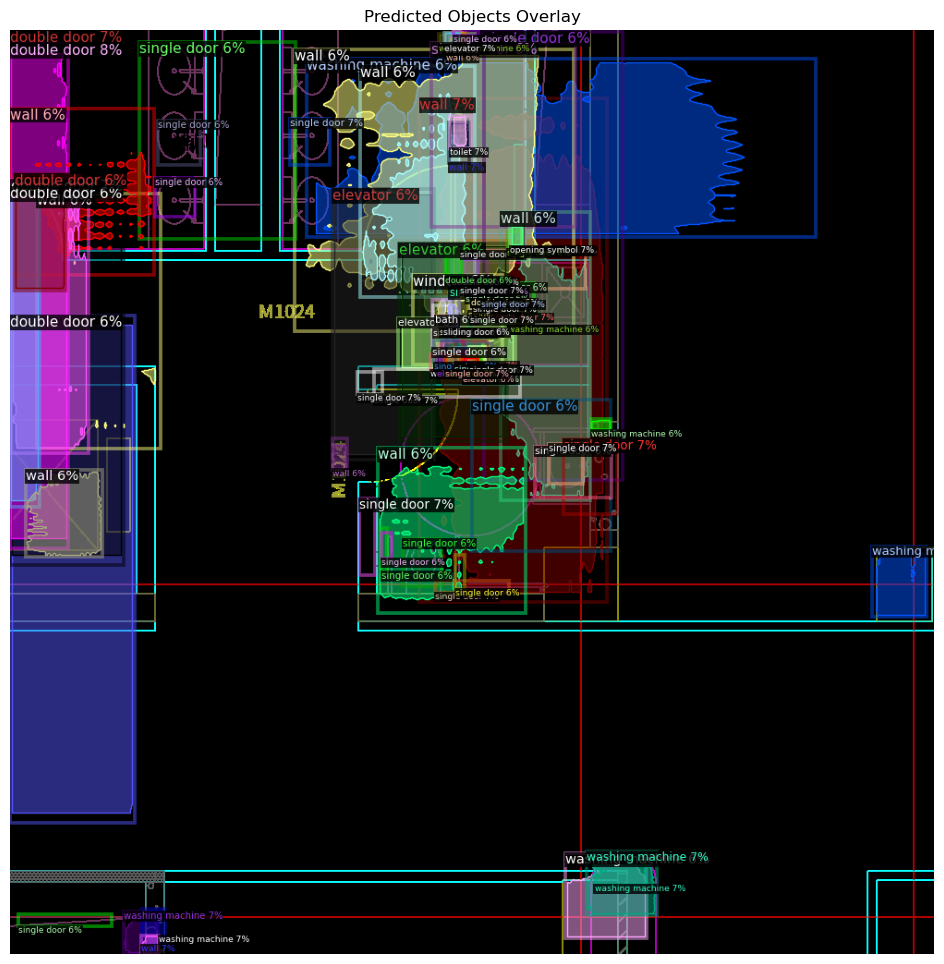

In [26]:
img_path = "Data/images/test-00/0006-0013.png"
image = cv2.imread(img_path)
outputs = predictor(image)

# Reverse channel order from BGR (OpenCV) to RGB (matplotlib)
image_rgb = image[:, :, ::-1]

# Get metadata for class labels and colors
metadata = MetadataCatalog.get("floorplan_test_00")

# Create the visualizer
v = Visualizer(image_rgb, metadata=metadata, scale=1.0)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show the image
plt.figure(figsize=(12, 12))
plt.imshow(out.get_image())
plt.axis("off")
plt.title("Predicted Objects Overlay")
plt.show()

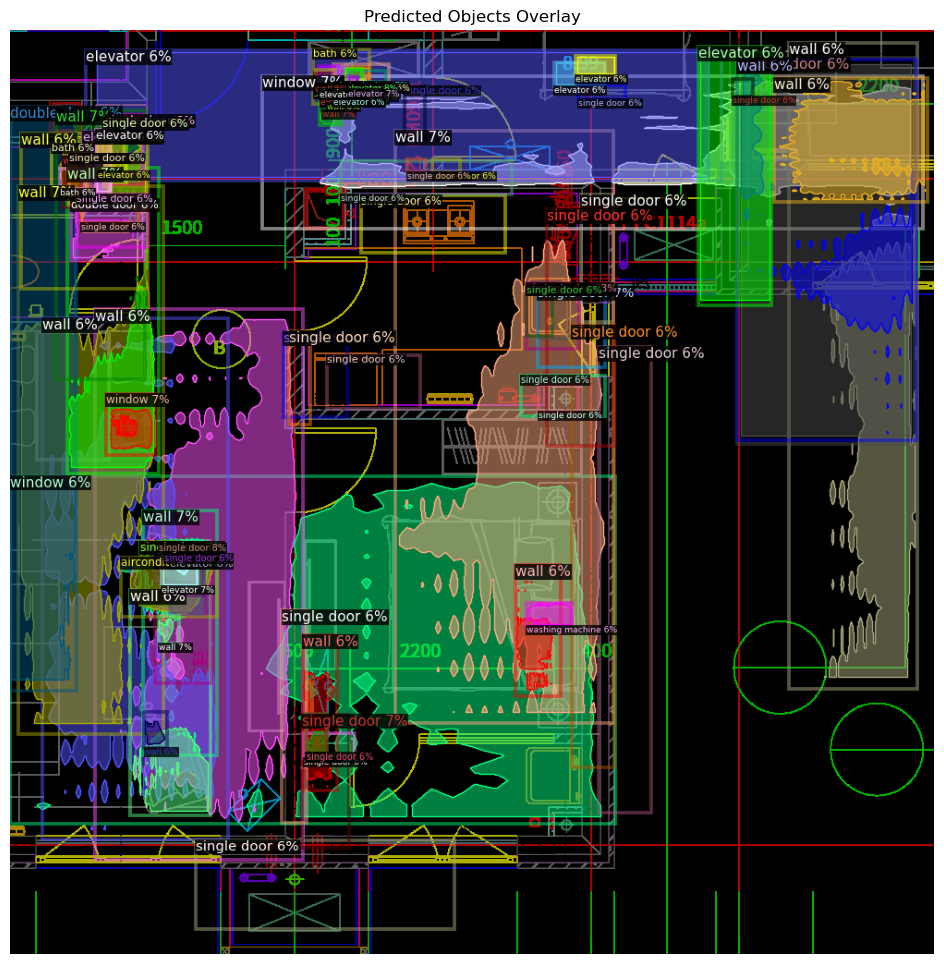

In [27]:
img_path = "Data/images/train-01/0001-0040.png"
image = cv2.imread(img_path)
outputs = predictor(image)

# Reverse channel order from BGR (OpenCV) to RGB (matplotlib)
image_rgb = image[:, :, ::-1]

# Get metadata for class labels and colors
metadata = MetadataCatalog.get("floorplan_test_00")

# Create the visualizer
v = Visualizer(image_rgb, metadata=metadata, scale=1.0)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Show the image
plt.figure(figsize=(12, 12))
plt.imshow(out.get_image())
plt.axis("off")
plt.title("Predicted Objects Overlay")
plt.show()